In [ ]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import auc, roc_curve, classification_report
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score, KFold,train_test_split, GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error,mean_squared_error
from xgboost.sklearn import XGBRegressor

import shap

%matplotlib inline

# 1. Load Data

In [ ]:
# Upload file from local drive
#from google.colab import files
#upload_file = files.upload()

In [ ]:
data = pd.read_csv('srdb-data.csv')

In [ ]:
data.head()

,Record_number,Entry_date,Study_number,Author,Duplicate_record,Quality_flag,Contributor,Country,Region,Site_name,...,BA,C_veg_total,C_AG,C_BG,C_CR,C_FR,C_litter,C_soilmineral,C_soildepth,Notes
0,1.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1998,...,0.0,200.0,80.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
1,2.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1995,...,0.5,160.0,90.0,70.0,40.0,30.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
2,3.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1989,...,0.0,520.0,400.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
3,4.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1981,...,4.1,1050.0,700.0,350.0,230.0,120.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
4,5.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1964,...,11.6,2300.0,1500.0,800.0,600.0,200.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12272 entries, 0 to 12271
Data columns (total 85 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record_number       12272 non-null  float64
 1   Entry_date          12272 non-null  object 
 2   Study_number        12272 non-null  int64  
 3   Author              12270 non-null  object 
 4   Duplicate_record    104 non-null    object 
 5   Quality_flag        3457 non-null   object 
 6   Contributor         12272 non-null  object 
 7   Country             12261 non-null  object 
 8   Region              9454 non-null   object 
 9   Site_name           10830 non-null  object 
 10  Site_ID             11753 non-null  object 
 11  Study_midyear       12078 non-null  float64
 12  YearsOfData         12074 non-null  float64
 13  Latitude            11883 non-null  float64
 14  Longitude           11881 non-null  float64
 15  Elevation           7053 non-null   float64
 16  Mani

In [ ]:
"""
for column in features:
    if pd.api.types.is_string_dtype(data[column]):
        uniques = sorted(data[column].unique())
        print('{0:20s} {1:5d}\t'.format(column, len(uniques)), uniques[:5])
"""

"\nfor column in features:\n    if pd.api.types.is_string_dtype(data[column]):\n        uniques = sorted(data[column].unique())\n        print('{0:20s} {1:5d}\t'.format(column, len(uniques)), uniques[:5])\n"

In [1]:
data_new = data.loc[~data['Rs_annual'].isna()]

NameError: name 'data' is not defined

In [ ]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6763 entries, 0 to 12271
Data columns (total 85 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record_number       6763 non-null   float64
 1   Entry_date          6763 non-null   object 
 2   Study_number        6763 non-null   int64  
 3   Author              6763 non-null   object 
 4   Duplicate_record    70 non-null     object 
 5   Quality_flag        1860 non-null   object 
 6   Contributor         6763 non-null   object 
 7   Country             6761 non-null   object 
 8   Region              4972 non-null   object 
 9   Site_name           6041 non-null   object 
 10  Site_ID             6398 non-null   object 
 11  Study_midyear       6703 non-null   float64
 12  YearsOfData         6715 non-null   float64
 13  Latitude            6606 non-null   float64
 14  Longitude           6604 non-null   float64
 15  Elevation           3912 non-null   float64
 16  Manipulati

# 2. EDA

In [ ]:
data['Study_midyear'].head()


,Study_midyear
0,2001.5
1,2001.5
2,2001.5
3,2001.5
4,2001.5


In [ ]:
data['Study_year'] = np.floor(data['Study_midyear'])

In [ ]:
col='Quality_flag'
uniques = data[col].unique()
print('{0:20s} {1:5d}\t'.format(col, len(uniques)), uniques)

Quality_flag            32	 ['Q02' 'Q01' nan 'Q10' 'Q03' 'Q2' 'Q1,Q10' 'Q03,Q10,Q16' 'Q11' 'Q16'
 'Q10,Q13' 'Q03,Q12' 'Q01,Q11' 'Q03,Q10' 'Q12' 'Q13' 'Q03,Q13' 'Q01,Q13'
 'Q01,Q03' 'Q04' 'Q03, Q11' 'Q15' 'Q01,Q10' 'Q11,Q12' 'Q01,Q16' 'Q01, Q11'
 'Q11,Q14' 'Q1' 'Q01,Q14' 'Q3' 'Q01, Q03' 'Q0']


In [ ]:
data[col].unique()

array(['Q02', 'Q01', nan, 'Q10', 'Q03', 'Q2', 'Q1,Q10', 'Q03,Q10,Q16',
       'Q11', 'Q16', 'Q10,Q13', 'Q03,Q12', 'Q01,Q11', 'Q03,Q10', 'Q12',
       'Q13', 'Q03,Q13', 'Q01,Q13', 'Q01,Q03', 'Q04', 'Q03, Q11', 'Q15',
       'Q01,Q10', 'Q11,Q12', 'Q01,Q16', 'Q01, Q11', 'Q11,Q14', 'Q1',
       'Q01,Q14', 'Q3', 'Q01, Q03', 'Q0'], dtype=object)

In [ ]:
"""
Quality_flag
Quality control flags are as follows:
		Q0	default (none)
		Q01	estimated from figure
		Q02	data from another study
		Q03	data estimated--other
		Q04	potentially useful future data
		Q10	potential problem with data
		Q11	suspected problem with data
		Q12	known problem with data
		Q13	duplicate?
		Q14	inconsistency
		Q15	seasonal model, not annual
		Q16	model has a soil water component or dependency


"""

'\nQuality_flag\nQuality control flags are as follows:\n\t\tQ0\tdefault (none)\n\t\tQ01\testimated from figure\n\t\tQ02\tdata from another study\n\t\tQ03\tdata estimated--other\n\t\tQ04\tpotentially useful future data\n\t\tQ10\tpotential problem with data\n\t\tQ11\tsuspected problem with data\n\t\tQ12\tknown problem with data\n\t\tQ13\tduplicate?\n\t\tQ14\tinconsistency\n\t\tQ15\tseasonal model, not annual\n\t\tQ16\tmodel has a soil water component or dependency\n\n\n'

<AxesSubplot:xlabel='Rs_annual', ylabel='Density'>

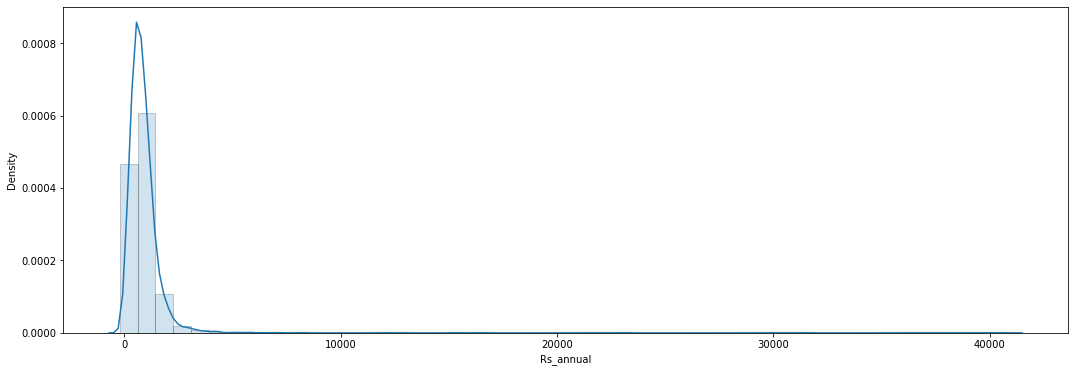

In [ ]:
col = 'Rs_annual'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
hist_kws={'histtype': 'bar', 'edgecolor':'black', 'alpha': 0.2}
sns.distplot(data[col], label='Rs_annual',
             hist_kws=hist_kws)

Text(0.5, 1.0, 'Rs_annual vs MAT')

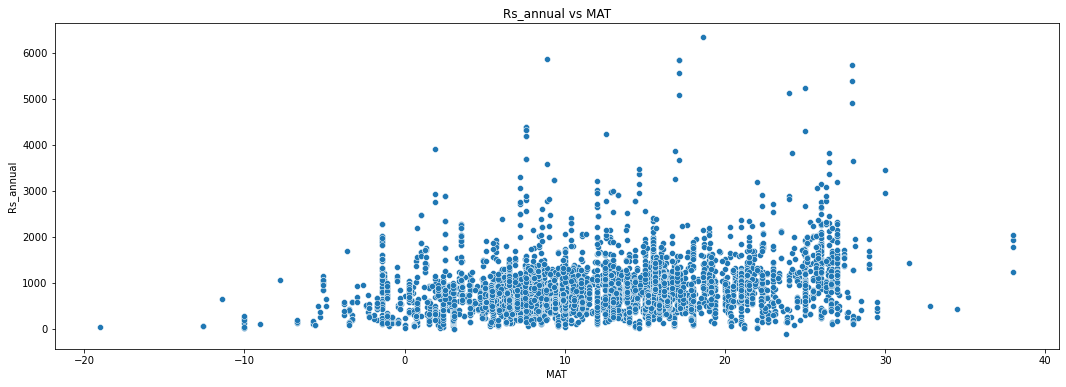

In [ ]:
y_col = 'Rs_annual'
x_col = 'MAT'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
sns.scatterplot(x=x_col, y=y_col, data=data, ax=ax)
ax.set_title('Rs_annual vs MAT')


Text(0.5, 1.0, 'Rs_annual vs MAP')

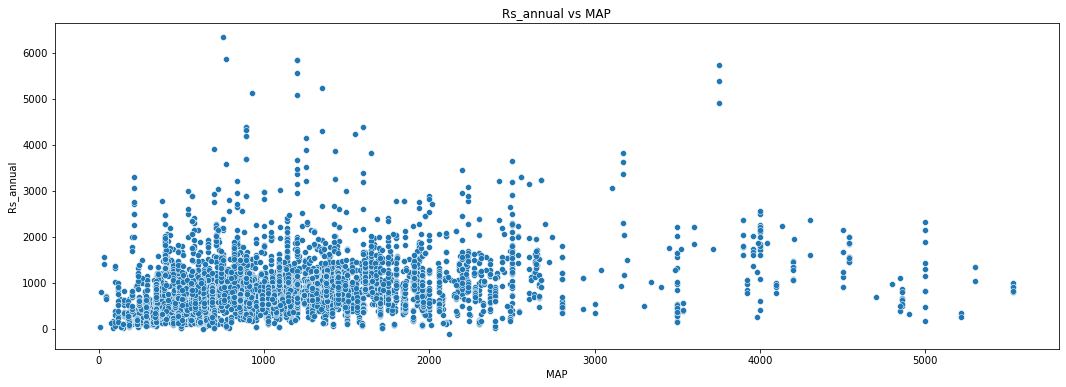

In [ ]:
y_col = 'Rs_annual'
x_col = 'MAP'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
sns.scatterplot(x=x_col, y=y_col, data=data, ax=ax)
ax.set_title('Rs_annual vs MAP')


## 2.1 Data cleaning


In [ ]:
accept_flag =['Q02', 'Q01', 'Q03', 'Q2',
       'Q01,Q03', 'Q04',  'Q1',
    'Q3', 'Q01, Q03', 'Q0']

In [ ]:
clean_data = data.loc[((data['Quality_flag'].isna())|(data['Quality_flag'].isin(accept_flag))) & (~data['Rs_annual'].isna())]

In [ ]:
print('Original # row:', len(data), 'Clean # rows:', len(clean_data))

Original # row: 12272 Clean # rows: 6397


## 2.2 Feature selection

In [ ]:
# Explanatory variables:
"""
Spatial–Temporal Data
13,YearsOfData,Years of data; always ?1
14,Latitude,"Latitude, decimal (positive=north, negative=south)"
15,Longitude,"Longitude, decimal (positive=east, negative=west)"
16,Elevation,"Elevation, m"
22,Biome,"Biome (boreal, temperate, etc). Subjective"

Climate data
34,MAT,"Reported mean annual temperature, deg C"
35,MAP,"Reported mean annual precipitation, mm"

Vegetation data
25,Leaf_habit,"Dominant leaf habit (deciduous, evergreen)"
26,Stage,"Developmental stage (aggrading, mature). Subjective"
75,LAI,"Leaf area index at site, m2 m-2. Hemispheric (one-sided) if possible"

Soil data
27,Soil_type,Soil description (classification and texture)
28,Soil_drainage,"Soil drainage (dry, wet). Subjective. 'Dry' means well-drained uplands; 'wet' peatlands, swamps, etc."
29,Soil_BD,"Soil bulk density, g cm-3"
30,Soil_CN, Soil C:N ratio
31,Soil_sand, Sand ratio value (generally sand+silt+clay = 100 but not always)
32,Soil_silt, Silt ratio value (generally sand+silt+clay = 100 but not always)
33,Soil_clay, Clay ratio value (generally sand+silt+clay = 100 but not always)

Land use data
23,Ecosystem_type,"Ecosystem type (grassland, forest, etc). Subjective"
24,Ecosystem_state,"Ecosystem state (managed, unmanaged, natural). Subjective. 'Unmanaged' means human management or disturbance in the past, but not currently."

"""

'\nSpatial–Temporal Data\n13,YearsOfData,Years of data; always ?1\n14,Latitude,"Latitude, decimal (positive=north, negative=south)"\n15,Longitude,"Longitude, decimal (positive=east, negative=west)"\n16,Elevation,"Elevation, m"\n22,Biome,"Biome (boreal, temperate, etc). Subjective"\n\nClimate data\n34,MAT,"Reported mean annual temperature, deg C"\n35,MAP,"Reported mean annual precipitation, mm"\n\nVegetation data\n25,Leaf_habit,"Dominant leaf habit (deciduous, evergreen)"\n26,Stage,"Developmental stage (aggrading, mature). Subjective"\n75,LAI,"Leaf area index at site, m2 m-2. Hemispheric (one-sided) if possible"\n\nSoil data\n27,Soil_type,Soil description (classification and texture)\n28,Soil_drainage,"Soil drainage (dry, wet). Subjective. \'Dry\' means well-drained uplands; \'wet\' peatlands, swamps, etc."\n29,Soil_BD,"Soil bulk density, g cm-3"\n30,Soil_CN, Soil C:N ratio\n31,Soil_sand, Sand ratio value (generally sand+silt+clay = 100 but not always)\n32,Soil_silt, Silt ratio value (g

In [ ]:
spatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']
climate_features = ['MAT', 'MAP']
vegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]
landuse_features = ['Ecosystem_type', 'Ecosystem_state']
soil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']

### Climate features

In [ ]:
data[climate_features].head()

,MAT,MAP
0,0.8,450.0
1,0.8,450.0
2,0.8,450.0
3,0.8,450.0
4,0.8,450.0


In [ ]:
print('Missing values:')
data[climate_features].isna().sum()/len(data)

Missing values:


,0
MAT,0.255460
MAP,0.195893


### Spatial_temporal_features

In [ ]:
data[spatial_temporal_features].head()

,YearsOfData,Latitude,Longitude,Elevation,Biome
0,1.5,56.63,-99.94,NaN,Boreal
1,1.5,56.46,-99.97,NaN,Boreal
2,1.5,55.91,-98.98,NaN,Boreal
3,1.5,55.86,-98.48,NaN,Boreal
4,1.5,55.92,-98.39,NaN,Boreal


In [ ]:
print('Missing values:')
data[spatial_temporal_features].isna().sum()/len(data)

Missing values:


YearsOfData    0.016134
Latitude       0.031698
Longitude      0.031861
Elevation      0.425277
Biome          0.020698
dtype: float64

#### A lot of missing values in "Elevation"

### Vegetation features

In [ ]:
data[vegetation_features].head()

,Leaf_habit,Stage,LAI
0,Evergreen,Aggrading,0.0
1,Deciduous,Aggrading,0.1
2,Deciduous,Aggrading,0.0
3,Mixed,Aggrading,0.9
4,Evergreen,Aggrading,1.8


In [ ]:
data[vegetation_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12272 entries, 0 to 12271
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Leaf_habit  11857 non-null  object 
 1   Stage       11946 non-null  object 
 2   LAI         965 non-null    float64
dtypes: float64(1), object(2)
memory usage: 287.8+ KB


In [ ]:
print('Missing values:')
data[vegetation_features].isna().sum()/len(data)

Missing values:


Leaf_habit    0.033817
Stage         0.026565
LAI           0.921366
dtype: float64

#### A lot of missing values in "LAI"

### Land use features

In [ ]:
data[landuse_features].head()

,Ecosystem_type,Ecosystem_state
0,Forest,Natural
1,Forest,Natural
2,Forest,Natural
3,Forest,Natural
4,Forest,Natural


In [ ]:
print('Missing values:')
data[landuse_features].isna().sum()/len(data)

Missing values:


Ecosystem_type     0.007171
Ecosystem_state    0.008882
dtype: float64

### Soil features

In [ ]:
data[soil_features].head()

,Soil_type,Soil_drainage,Soil_BD,Soil_CN,Soil_sand,Soil_silt,Soil_clay
0,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN
1,Gray luvisol (Boralf),Dry,NaN,NaN,NaN,NaN,NaN
2,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN
3,Gray luvisol (Boralf),Dry,NaN,NaN,NaN,NaN,NaN
4,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN


In [ ]:
data[soil_features].describe()

,Soil_BD,Soil_CN,Soil_sand,Soil_silt,Soil_clay
count,3398.000000,2864.000000,2059.000000,2050.000000,2169.000000
mean,1.117124,16.541947,45.991585,32.964813,21.181749
std,0.435891,10.390204,23.193085,17.674867,14.062656
min,0.050000,0.230000,0.600000,0.018100,0.000000
25%,0.950000,10.330000,29.600000,20.000000,11.000000
50%,1.200000,13.320000,45.000000,32.500000,20.000000
75%,1.330000,20.000000,62.750000,42.800000,28.000000
max,9.300000,113.200000,99.300000,85.000000,76.000000


In [ ]:
print('Missing values:')
data[soil_features].isna().sum()/len(data)

Missing values:


Soil_type        0.205590
Soil_drainage    0.034958
Soil_BD          0.723110
Soil_CN          0.766623
Soil_sand        0.832220
Soil_silt        0.832953
Soil_clay        0.823256
dtype: float64

# 3. Construct model


## 3.1 Feature encoding

In [ ]:
"""
spatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']
climate_features = ['MAT', 'MAP']
vegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]
landuse_features = ['Ecosystem_type', 'Ecosystem_state']
soil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']
"""

"\nspatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']\nclimate_features = ['MAT', 'MAP']\nvegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]\nlanduse_features = ['Ecosystem_type', 'Ecosystem_state']\nsoil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']\n"

In [ ]:
# label encoding
columns = ['Leaf_habit', 'Stage', 'Elevation', 'Biome', 'Ecosystem_type', 'Ecosystem_state', 'Soil_type', 'Soil_drainage']

for col in columns:
    clean_data[col] = data[col].astype(str)

    # one hot encoding
    enc = LabelEncoder()
    # fit transform training dataset
    enc_data = pd.DataFrame(enc.fit_transform(clean_data[[col]]))
    col_name = col+'_label'
    clean_data[col_name] = enc_data

In [ ]:
# Includ all features
features =['Study_year', 'YearsOfData', 'Latitude', 'Longitude', 'Elevation_label', 'Biome_label',
    'MAT', 'MAP',
    'Leaf_habit_label', 'Stage_label',
    'Ecosystem_type_label', 'Ecosystem_state_label',
    'Soil_type_label', 'Soil_drainage_label',
    'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay',
    'LAI']

target = 'Rs_annual'

In [ ]:

features =['Study_year', 'YearsOfData', 'Latitude', 'Longitude', 'Elevation_label', 'Biome_label',
    'MAT', 'MAP',
    'Leaf_habit_label', 'Stage_label',
    'Ecosystem_type_label', 'Ecosystem_state_label',
    'Soil_type_label', 'Soil_drainage_label']

target = 'Rs_annual'

In [ ]:
#clean_data[features] = clean_data[features].fillna(clean_data[features].median())

In [ ]:
clean_data[features].isna().sum()

Study_year                 56
YearsOfData                45
Latitude                  156
Longitude                 158
Elevation_label          2726
Biome_label              2726
MAT                      1428
MAP                      1087
Leaf_habit_label         2726
Stage_label              2726
Ecosystem_type_label     2726
Ecosystem_state_label    2726
Soil_type_label          2726
Soil_drainage_label      2726
dtype: int64

In [ ]:
clean_data[target].isna().sum()

0

## 3.2 Train-test split

In [ ]:
#Train and test sets split: train - 70%, test -30%
train, test = train_test_split(clean_data[features+[target]], test_size=0.3, random_state=2)

In [ ]:
train.sample(2)

,Study_year,YearsOfData,Latitude,Longitude,Elevation_label,Biome_label,MAT,MAP,Leaf_habit_label,Stage_label,Ecosystem_type_label,Ecosystem_state_label,Rs_annual
1415,2004.0,1.3,49.850,-125.32,552.0,9.0,8.6,1452.0,0.0,0.0,0.0,0.0,1200.0
3694,2002.0,1.0,31.333,35.05,508.0,8.0,NaN,NaN,1.0,2.0,4.0,0.0,453.8


In [ ]:
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [ ]:
y_train.isna().sum()

0

## 3.2 Model Training

### Hyper-parameter tuning

In [ ]:
xgb_model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468,
                             learning_rate=0.05, max_depth=3,
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)

In [ ]:
# grid search xgboost hyperparameter
xgb_params = {
    "n_estimators": [500],
    "max_depth": [7, 10],
    "learning_rate": [ 0.05, .1],
    "subsample": [0.6, 0.9],
}
kfold = KFold(n_splits=3, shuffle=True, random_state=1)
xgb_grid = GridSearchCV(XGBRegressor(), xgb_params, verbose=5, scoring='neg_mean_squared_error', n_jobs=-1, cv=kfold)
xgb_grid_result = xgb_grid.fit(X_train.values, y_train.values.ravel())

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
# summary of results
print ("Best: %f using %s" % (xgb_grid_result.best_score_, xgb_grid_result.best_params_))
means = xgb_grid_result.cv_results_['mean_test_score']
stds = xgb_grid_result.cv_results_['std_test_score']
params = xgb_grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print ("%f (%f) with: %r" % (mean, stdev, param))

Best: -565022.890427 using {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.9}
-571415.963849 (370121.543344) with: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.6}
-565022.890427 (371540.574866) with: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.9}
-567810.199036 (371130.144901) with: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.6}
-569951.729458 (368532.797520) with: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.9}
-605630.308450 (356832.613247) with: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.6}
-574766.571968 (369841.863267) with: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.9}
-604291.986089 (355581.205795) with: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.6}
-577157.135546 (370957.996848) with: {'learning_rate': 0.1, 'max_depth': 10, 'n_es

In [ ]:
xgb_model = xgb_grid.best_estimator_
xgb_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### Run model without hyper-parameter tuning

In [ ]:
"""
xgb_model =XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.05, max_delta_step=0, max_depth=7,
             min_child_weight=1, monotone_constraints='()',
             n_estimators=500, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.9,
             tree_method='exact', validate_parameters=1, verbosity=None)
"""

In [ ]:
xgb_model_results = xgb_model.fit(X_train.values, y_train.values.ravel())

In [ ]:
train_predict = xgb_model.predict(X_train.values)

In [ ]:
train_predict

array([ 931.7608 , 1397.0583 ,  619.419  , ...,  454.58588, 1095.1182 ,
        519.8128 ], dtype=float32)

In [ ]:
print('Train MAE : %f' % (mean_absolute_error(y_train, train_predict)))
print('Train RMSE : %f' % (np.sqrt(mean_squared_error(y_train, train_predict))))
print('Train R2 : %f' % (r2_score(y_train, train_predict)))
print('\n')

Train MAE : 133.985436
Train RMSE : 566.104762
Train R2 : 0.595841




In [ ]:
test_predict = xgb_model.predict(X_test.values)
print('Test MAE : %f' % (mean_absolute_error(y_test, test_predict)))
print('Test RMSE : %f' % (np.sqrt(mean_squared_error(y_test, test_predict))))
print('Test R2 : %f' % (r2_score(y_test, test_predict)))

Test MAE : 231.836081
Test RMSE : 601.192041
Test R2 : 0.623307


# 4 Feature importance and SHAP

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)
shap_values.shape

(4477, 20)

## Global feature importance

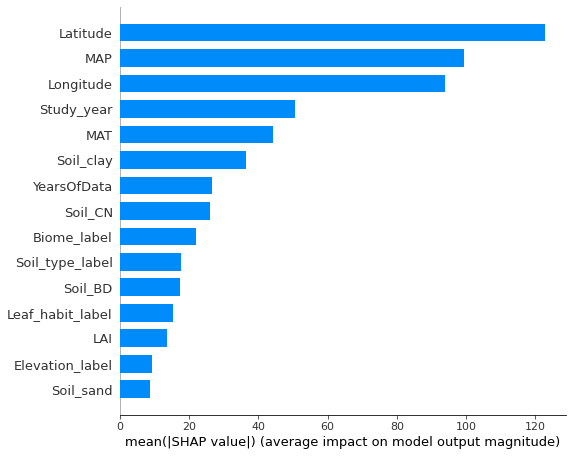

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=15)

## Importance Density, Dispersion, and Directionality

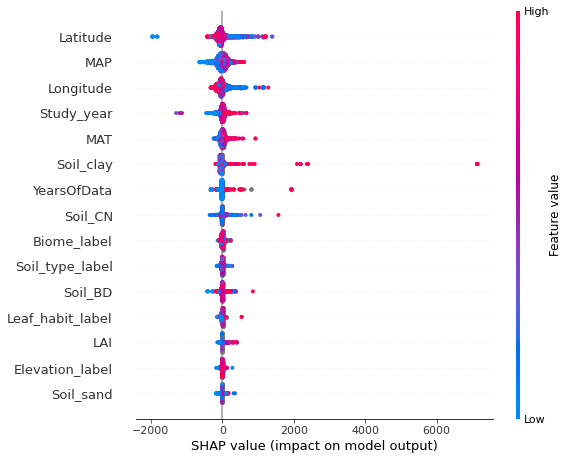

In [ ]:
shap.summary_plot(shap_values, X_train, max_display=15)

## Partial Dependence and Interaction Effects

#### MAP

In [ ]:
print(data['MAP'].max())

5532.0


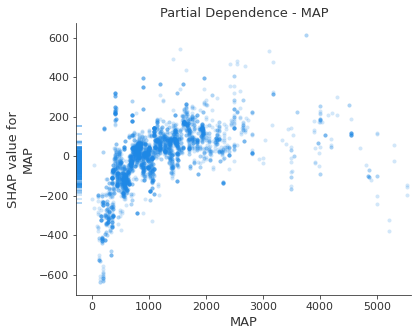

In [ ]:
shap.dependence_plot('MAP', shap_values, X_train, xmax=5600, interaction_index=None,
                     title='Partial Dependence - MAP', alpha=0.2)

#### MAT

In [ ]:
print(data['MAT'].max())

38.0


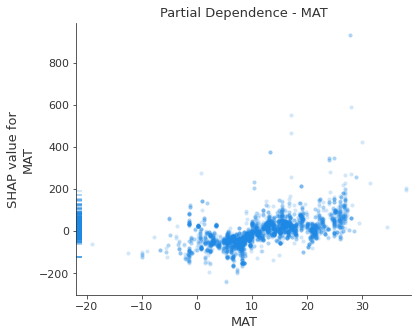

In [ ]:
shap.dependence_plot('MAT', shap_values, X_train, xmax=39, interaction_index=None,
                     title='Partial Dependence - MAT', alpha=0.2)

#### Interation between MAP and MAT

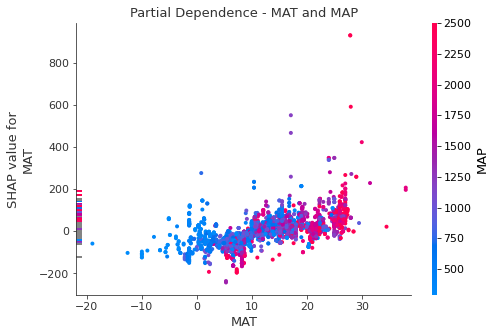

In [ ]:
shap.dependence_plot('MAT', shap_values, X_train, xmax=39, interaction_index='MAP',
                     title='Partial Dependence - MAT and MAP')

## Explanation for individual predictions

In [ ]:
predicted_y = xgb_model.predict(X_test[:20].values)
sv_test = explainer.shap_values(X_test[:20].values)
print(predicted_y.shape, sv_test.shape)

(20,) (20, 20)


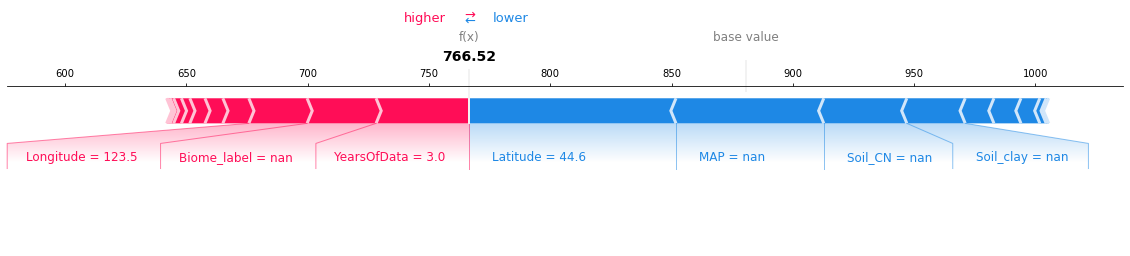

In [ ]:
shap.force_plot(explainer.expected_value, sv_test[8,:], X_test.iloc[8,:], matplotlib=True)

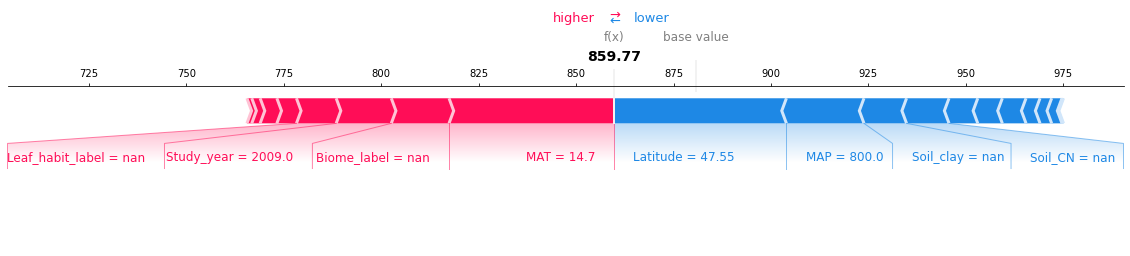

In [ ]:
shap.force_plot(explainer.expected_value, sv_test[0,:], X_test.iloc[0,:], matplotlib=True)

# 5. Neural Network

In [ ]:
X_train.fillna(X_train.median(), inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data
scaler.fit(X_train)

# Transform the training and testing data
X_train_scaled = scaler.transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [ ]:
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(1) # Output layer with linear activation for regression
])

# Compile the model
model.compile(optimizer='adam',
              loss='mean_squared_error', # MSE loss for regression
              metrics=['mae']) # Mean Absolute Error metric for regression

# Train the model
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32)


Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1576809.1250 - mae: 880.4778
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 855976.4375 - mae: 665.0574
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1380921.1250 - mae: 424.7487
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1609700.5000 - mae: 442.6337
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 619886.2500 - mae: 406.4301
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 849824.6250 - mae: 404.8144
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2298261.2500 - mae: 438.0865
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 454532.6562 - mae: 391.2065
Epoch 9/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 402371.7812 - mae: 388.3314
Epoch 10/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 769070.1875 - mae: 413.8364
Epoch 11/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 815893.6250 - mae: 397.9510
Epoch 12/100
14

In [ ]:
X_train.head()

,Study_year,YearsOfData,Latitude,Longitude,Elevation_label,Biome_label,MAT,MAP,Leaf_habit_label,Stage_label,Ecosystem_type_label,Ecosystem_state_label,Soil_type_label,Soil_drainage_label,Soil_BD,Soil_CN,Soil_sand,Soil_silt,Soil_clay,LAI
10116,2012.0,1.0,42.620,2.420,NaN,NaN,12.0,664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.00,32.00,19.00,NaN
877,1991.0,1.0,39.080,-96.580,552.0,11.0,12.5,835.0,1.0,2.0,4.0,2.0,742.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
7692,2014.0,1.0,35.216,107.666,NaN,NaN,9.4,560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.125,NaN,NaN,NaN,NaN
8869,2010.0,1.0,40.310,-3.450,NaN,NaN,19.0,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.38,41.28,27.34,NaN
7442,2012.0,1.0,-21.250,-48.300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.00,10.00,29.00,NaN


In [ ]:
y_train.head()

,Rs_annual
10116,1069.45
877,1613.00
7692,756.87
8869,1179.36
7442,1560.00


In [ ]:
train_predict = model.predict(X_train_scaled)

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print('Train MAE : %f' % (mean_absolute_error(y_train, train_predict)))
print('Train RMSE : %f' % (np.sqrt(mean_squared_error(y_train, train_predict))))
print('Train R2 : %f' % (r2_score(y_train, train_predict)))
print('\n')

Train MAE : 341.000177
Train RMSE : 758.947877
Train R2 : 0.273590


